# Importing

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Applied Data Science/Semester 2/Capstone Project/6 class csv.csv')

# Background

In [3]:
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O
237,8829,537493.000000,1423.0000,-10.73,5,White,A
238,9235,404940.000000,1112.0000,-11.23,5,White,A


In [4]:
df.columns

Index(['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
       'Absolute magnitude(Mv)', 'Star type', 'Star color', 'Spectral Class'],
      dtype='object')

In [5]:
df.dtypes

Temperature (K)             int64
Luminosity(L/Lo)          float64
Radius(R/Ro)              float64
Absolute magnitude(Mv)    float64
Star type                   int64
Star color                 object
Spectral Class             object
dtype: object

In [6]:
df.isna().sum()

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.2+ KB


In [8]:
df['Spectral Class'].unique()

array(['M', 'B', 'A', 'F', 'O', 'K', 'G'], dtype=object)

In [9]:
df['Star color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'Blue ',
       'yellowish', 'Yellowish', 'Orange-Red', 'Blue white ',
       'Blue-White'], dtype=object)

# Encoding

In [10]:
import numpy as np
def str_cleanup(Str):
    Str = Str.capitalize()  # Capitalize the first letter
    Str = Str.strip()       # Remove leading and trailing whitespaces
    Str = Str.replace('-', ' ')  # Replace hyphens with spaces
    return Str

# Assuming X_train is your DataFrame and 'Star color' is the column containing color labels
df['Star Color Map'] = np.vectorize(str_cleanup)(df['Star color'])

In [11]:
df['Star Color Map'].unique()

array(['Red', 'Blue white', 'White', 'Yellowish white',
       'Pale yellow orange', 'Blue', 'Whitish', 'Yellow white', 'Orange',
       'White yellow', 'Yellowish', 'Orange red'], dtype=object)

In [12]:
color_map = {
   'Red':0,'Blue white':1, 'White':2, 'Yellowish white':3,
       'Pale yellow orange':4, 'Blue':5, 'Whitish':6, 'Yellow white':7, 'Orange':8,
       'White yellow':9, 'Yellowish':10, 'Orange red':11
}

In [13]:
df['Star Color Code'] = df['Star Color Map'].map(color_map)

In [14]:
df['Star Color Code'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [15]:
df['Spectral Class'].unique()

array(['M', 'B', 'A', 'F', 'O', 'K', 'G'], dtype=object)

In [16]:
Spectral_Class_Map = { 'M': 0, 'B': 1, 'A':2, 'F':3, 'O':4, 'K':5, 'G':6}

In [17]:
df['Spectral Class Map'] = df['Spectral Class'].map(Spectral_Class_Map)

In [18]:
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class,Star Color Map,Star Color Code,Spectral Class Map
0,3068,0.002400,0.1700,16.12,0,Red,M,Red,0,0
1,3042,0.000500,0.1542,16.60,0,Red,M,Red,0,0
2,2600,0.000300,0.1020,18.70,0,Red,M,Red,0,0
3,2800,0.000200,0.1600,16.65,0,Red,M,Red,0,0
4,1939,0.000138,0.1030,20.06,0,Red,M,Red,0,0
...,...,...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O,Blue,5,4
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O,Blue,5,4
237,8829,537493.000000,1423.0000,-10.73,5,White,A,White,2,2
238,9235,404940.000000,1112.0000,-11.23,5,White,A,White,2,2


# Machine Learning


In [19]:
df.columns

Index(['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)',
       'Absolute magnitude(Mv)', 'Star type', 'Star color', 'Spectral Class',
       'Star Color Map', 'Star Color Code', 'Spectral Class Map'],
      dtype='object')

In [20]:
import xgboost as xgb

In [21]:
features = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)',
            'Star Color Code']

In [22]:
X = df[features]
y = df['Star type']

In [23]:
# Initialize XGBoost model
model = xgb.XGBClassifier()

# Fit the model to the entire dataset
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [24]:
df['My Prediction'] = model.predict(X)

In [25]:
from sklearn.metrics import accuracy_score

# Calculate accuracy using scikit-learn
accuracy = accuracy_score(df['Star type'], df['My Prediction'])
print("Accuracy:", accuracy)

Accuracy: 1.0


From this I can tell that my predictions matched that of the actual Star types

In [26]:
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class,Star Color Map,Star Color Code,Spectral Class Map,My Prediction
0,3068,0.002400,0.1700,16.12,0,Red,M,Red,0,0,0
1,3042,0.000500,0.1542,16.60,0,Red,M,Red,0,0,0
2,2600,0.000300,0.1020,18.70,0,Red,M,Red,0,0,0
3,2800,0.000200,0.1600,16.65,0,Red,M,Red,0,0,0
4,1939,0.000138,0.1030,20.06,0,Red,M,Red,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O,Blue,5,4,5
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O,Blue,5,4,5
237,8829,537493.000000,1423.0000,-10.73,5,White,A,White,2,2,5
238,9235,404940.000000,1112.0000,-11.23,5,White,A,White,2,2,5


## Star Type Map

In [27]:
df['Star type'].unique()

array([0, 1, 2, 3, 4, 5])

In [28]:
star_type_map = {0: 'Brown Dwarf', 1:'Red Dwarf', 2:'White Dwarf',
                 3:'Main Sequence', 4:'Supergiant', 5:'Hypergiant'}

In [29]:
df['MP Star Type String'] = df['My Prediction'].map(star_type_map)

In [30]:
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class,Star Color Map,Star Color Code,Spectral Class Map,My Prediction,MP Star Type String
0,3068,0.002400,0.1700,16.12,0,Red,M,Red,0,0,0,Brown Dwarf
1,3042,0.000500,0.1542,16.60,0,Red,M,Red,0,0,0,Brown Dwarf
2,2600,0.000300,0.1020,18.70,0,Red,M,Red,0,0,0,Brown Dwarf
3,2800,0.000200,0.1600,16.65,0,Red,M,Red,0,0,0,Brown Dwarf
4,1939,0.000138,0.1030,20.06,0,Red,M,Red,0,0,0,Brown Dwarf
...,...,...,...,...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O,Blue,5,4,5,Hypergiant
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O,Blue,5,4,5,Hypergiant
237,8829,537493.000000,1423.0000,-10.73,5,White,A,White,2,2,5,Hypergiant
238,9235,404940.000000,1112.0000,-11.23,5,White,A,White,2,2,5,Hypergiant


In [31]:
df['MP Star Type String'].unique()

array(['Brown Dwarf', 'Red Dwarf', 'White Dwarf', 'Main Sequence',
       'Supergiant', 'Hypergiant'], dtype=object)

# Data Analysis

In [ ]:
df.to_csv('/content/drive/MyDrive/Applied Data Science/Semester 2/Capstone Project/Star_Improved.csv', index=False)

In [32]:
import matplotlib.pyplot as plt

In [33]:
color_map_plot = { 'Red':'red','Blue white':'white', 'White':'white', 'Yellowish white':'white',
       'Pale yellow orange':'orange', 'Blue':'blue', 'Whitish':'white', 'Yellow white':'white', 'Orange':'orange',
       'White yellow':'yellow', 'Yellowish':'yellow', 'Orange red':'red' }

In [34]:
colors = df['Star color'].map(color_map_plot)

In [35]:
df['Star color'].isna().sum()

0

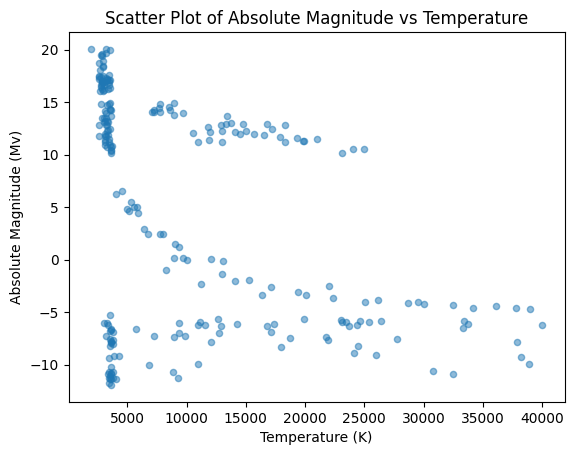

In [ ]:
# Create a scatter plot
df.plot.scatter(x='Temperature (K)', y='Absolute magnitude(Mv)', alpha=0.5)

# Add labels and title
plt.title('Scatter Plot of Absolute Magnitude vs Temperature')
plt.xlabel('Temperature (K)')
plt.ylabel('Absolute Magnitude (Mv)')

# Show the plot
plt.show()

In [ ]:
df

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class,Star Color Map,Star Color Code,Spectral Class Map,My Prediction,MP Star Type String
0,3068,0.002400,0.1700,16.12,0,Red,M,Red,0,0,0,Brown Dwarf
1,3042,0.000500,0.1542,16.60,0,Red,M,Red,0,0,0,Brown Dwarf
2,2600,0.000300,0.1020,18.70,0,Red,M,Red,0,0,0,Brown Dwarf
3,2800,0.000200,0.1600,16.65,0,Red,M,Red,0,0,0,Brown Dwarf
4,1939,0.000138,0.1030,20.06,0,Red,M,Red,0,0,0,Brown Dwarf
...,...,...,...,...,...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O,Blue,5,4,5,Hypergiant
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O,Blue,5,4,5,Hypergiant
237,8829,537493.000000,1423.0000,-10.73,5,White,A,White,2,2,5,Hypergiant
238,9235,404940.000000,1112.0000,-11.23,5,White,A,White,2,2,5,Hypergiant


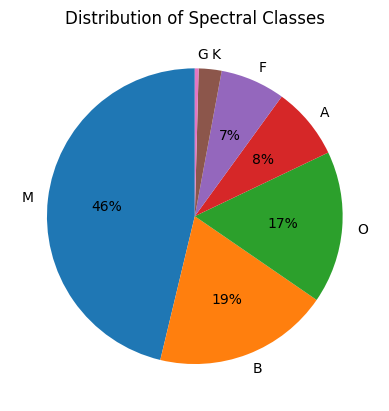

In [ ]:
# Counting the frequency of each Spectral Class
class_distribution = df['Spectral Class'].value_counts()

# Plotting pie chart
class_distribution.plot(kind='pie', autopct=lambda p: '{:.0f}%'.format(p) if p > 5 else '', startangle=90)
plt.title('Distribution of Spectral Classes')
plt.ylabel('')
plt.show()

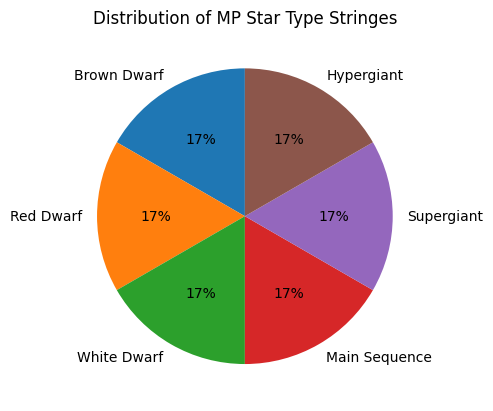

In [ ]:
# Counting the frequency of each MP Star Type String
class_distribution = df['MP Star Type String'].value_counts()

# Plotting pie chart
class_distribution.plot(kind='pie', autopct=lambda p: '{:.0f}%'.format(p) if p > 5 else '', startangle=90)
plt.title('Distribution of MP Star Type Stringes')
plt.ylabel('')
plt.show()

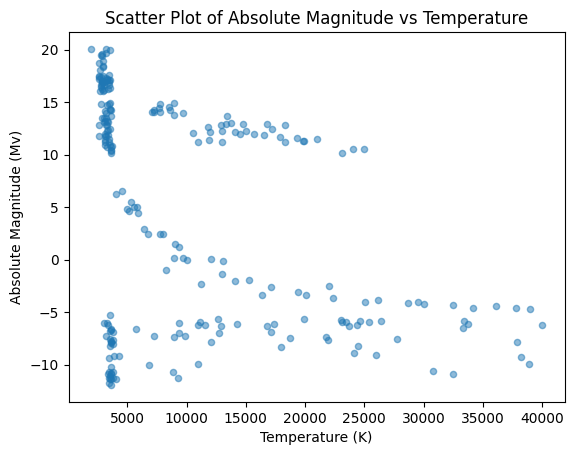

In [ ]:
# Create a scatter plot
df.plot.scatter(x='Temperature (K)', y='Absolute magnitude(Mv)', alpha=0.5)

# Add labels and title
plt.title('Scatter Plot of Absolute Magnitude vs Temperature')
plt.xlabel('Temperature (K)')
plt.ylabel('Absolute Magnitude (Mv)')

# Show the plot
plt.show()